# 🩸 Non-Invasive Glucose Estimation via PPG Signal
**Satria Data Competition — Statistics Essay Category**

---
## Dataset Structure
```
PPG_Dataset/
├── Figures/   → fig_XX_YYYY.jpg    (plot of each PPG recording)
├── Labels/    → label_XX_YYYY.mat  (subject info + glucose ground truth)
└── RawData/   → signal_XX_YYYY.mat (raw ADC signal, 10 sec @ 2190 Hz)
```
- `XX`   = Subject ID (01, 02, 03 ...)
- `YYYY` = Recording number per subject (0001, 0002 ...)

**Label contains:** Age, Glucose (mg/dL), Height (cm), Weight (kg), Gender  
**One label per recording** — the glucometer reading taken at the time of capture.

## Cell 1 — Imports & Config

In [3]:
import os, glob, struct, warnings
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import pandas as pd
from pymatreader import read_mat   # pip install pymatreader
warnings.filterwarnings('ignore')

# ── CONFIG ──────────────────────────────────────
DATASET_ROOT = './'     # change if needed
RAW_DIR  = os.path.join(DATASET_ROOT, 'RawData')
LAB_DIR  = os.path.join(DATASET_ROOT, 'Labels')
FIG_DIR  = os.path.join(DATASET_ROOT, 'Figures')
FS       = 2190   # sampling frequency (Hz)
# ────────────────────────────────────────────────

print('Dataset root:', DATASET_ROOT)
print('Exists      :', os.path.exists(DATASET_ROOT))

Dataset root: ./
Exists      : True


## Cell 2 — Label Decoder

> **Why not `scipy.io`?**  
> The label `.mat` files store a **MATLAB Table (MCOS object)** which scipy cannot decode.  
> We use `pymatreader` to access the raw workspace bytes, then manually read  
> the 5 `float64` values stored at fixed offsets (`base=856`, `stride=64` bytes).
>
> Decoded fields in order: `Age → Glucose → Height → Weight → Gender`

In [4]:
def read_label(path: str) -> dict:
    """
    Decode a label_XX_YYYY.mat file.

    Returns a dict with keys:
        Age      (years)
        Glucose  (mg/dL)  ← target variable
        Height   (cm)
        Weight   (kg)
        Gender   (1 = Male, 2 = Female)

    Implementation note:
        The MATLAB Table is stored inside __function_workspace__ as raw bytes.
        Each field is a float64 (8 bytes) at base offset 856,
        with a 64-byte stride between each field.
    """
    raw    = read_mat(path)
    ws     = raw['__function_workspace__'].flatten().tobytes()
    BASE   = 856
    STRIDE = 64
    FIELDS = ['Age', 'Glucose', 'Height', 'Weight', 'Gender']

    result = {}
    for i, field in enumerate(FIELDS):
        offset        = BASE + i * STRIDE
        result[field] = struct.unpack('d', ws[offset:offset+8])[0]

    result['Gender_str'] = 'Female' if result['Gender'] == 2 else 'Male'
    return result


# Quick test
sample_label = sorted(glob.glob(os.path.join(LAB_DIR, 'label_*.mat')))[0]
info         = read_label(sample_label)

print(f'File: {os.path.basename(sample_label)}')
print('-' * 35)
for k, v in info.items():
    print(f'  {k:<12}: {v}')

File: label_01_0001.mat
-----------------------------------
  Age         : 38.0
  Glucose     : 99.0
  Height      : 180.0
  Weight      : 53.0
  Gender      : 2.0
  Gender_str  : Female


## Cell 3 — Load All Files → Master DataFrame

In [5]:
def parse_id(filepath):
    """Extract (subject_id, recording_id) from e.g. signal_01_0003.mat"""
    name  = os.path.basename(filepath).replace('.mat', '')
    parts = name.split('_')
    return int(parts[1]), int(parts[2])


signal_files = sorted(glob.glob(os.path.join(RAW_DIR, 'signal_*.mat')))
label_files  = sorted(glob.glob(os.path.join(LAB_DIR,  'label_*.mat')))

print(f'Signal files : {len(signal_files)}')
print(f'Label files  : {len(label_files)}')

rows = []
for sig_path, lab_path in zip(signal_files, label_files):
    subj, rec = parse_id(sig_path)
    label     = read_label(lab_path)
    rows.append({
        'subject'    : subj,
        'recording'  : rec,
        'signal_path': sig_path,
        **label
    })

df = pd.DataFrame(rows)
print()
print(df.to_string(index=False))

Signal files : 67
Label files  : 67

 subject  recording                  signal_path           Age       Glucose        Height        Weight        Gender Gender_str
       1          1 ./RawData/signal_01_0001.mat  3.800000e+01  9.900000e+01  1.800000e+02  5.300000e+01  2.000000e+00     Female
       1          2 ./RawData/signal_01_0002.mat  3.800000e+01  1.020000e+02  1.800000e+02  5.300000e+01  2.000000e+00     Female
       1          3 ./RawData/signal_01_0003.mat  3.800000e+01  1.030000e+02  1.800000e+02  5.300000e+01  2.000000e+00     Female
       1          4 ./RawData/signal_01_0004.mat  3.800000e+01  1.280000e+02  1.800000e+02  5.300000e+01  2.000000e+00     Female
       1          5 ./RawData/signal_01_0005.mat  3.800000e+01  1.300000e+02  1.800000e+02  5.300000e+01  2.000000e+00     Female
       1          6 ./RawData/signal_01_0006.mat  3.800000e+01  1.340000e+02  1.800000e+02  5.300000e+01  2.000000e+00     Female
       1          7 ./RawData/signal_01_0007.mat  3.8

## Cell 4 — Inspect a Single Signal File

In [6]:
sample_path = signal_files[0]
mat    = sio.loadmat(sample_path)
signal = mat['signal'].flatten().astype(float)
time   = np.arange(len(signal)) / FS

subj, rec = parse_id(sample_path)
label     = read_label(os.path.join(LAB_DIR, f'label_{subj:02d}_{rec:04d}.mat'))

print(f'File          : {os.path.basename(sample_path)}')
print(f'Variable name : signal')
print(f'Shape         : {signal.shape}')
print(f'Dtype         : uint16 (raw ADC values from sensor)')
print(f'Sampling rate : {FS} Hz')
print(f'Duration      : {len(signal)/FS:.1f} seconds')
print(f'Min / Max     : {signal.min():.0f} / {signal.max():.0f}')
print(f'Mean / Std    : {signal.mean():.2f} / {signal.std():.2f}')
print()
print(f'Subject {subj:02d} | Recording {rec:04d}')
print(f'  Glucose : {label["Glucose"]} mg/dL  ← TARGET')
print(f'  Age     : {label["Age"]}  | Gender : {label["Gender_str"]}')
print(f'  Height  : {label["Height"]} cm | Weight : {label["Weight"]} kg')

File          : signal_01_0001.mat
Variable name : signal
Shape         : (21900,)
Dtype         : uint16 (raw ADC values from sensor)
Sampling rate : 2190 Hz
Duration      : 10.0 seconds
Min / Max     : 495 / 526
Mean / Std    : 511.87 / 4.51

Subject 01 | Recording 0001
  Glucose : 99.0 mg/dL  ← TARGET
  Age     : 38.0  | Gender : Female
  Height  : 180.0 cm | Weight : 53.0 kg


## Cell 5 — Plot Signal

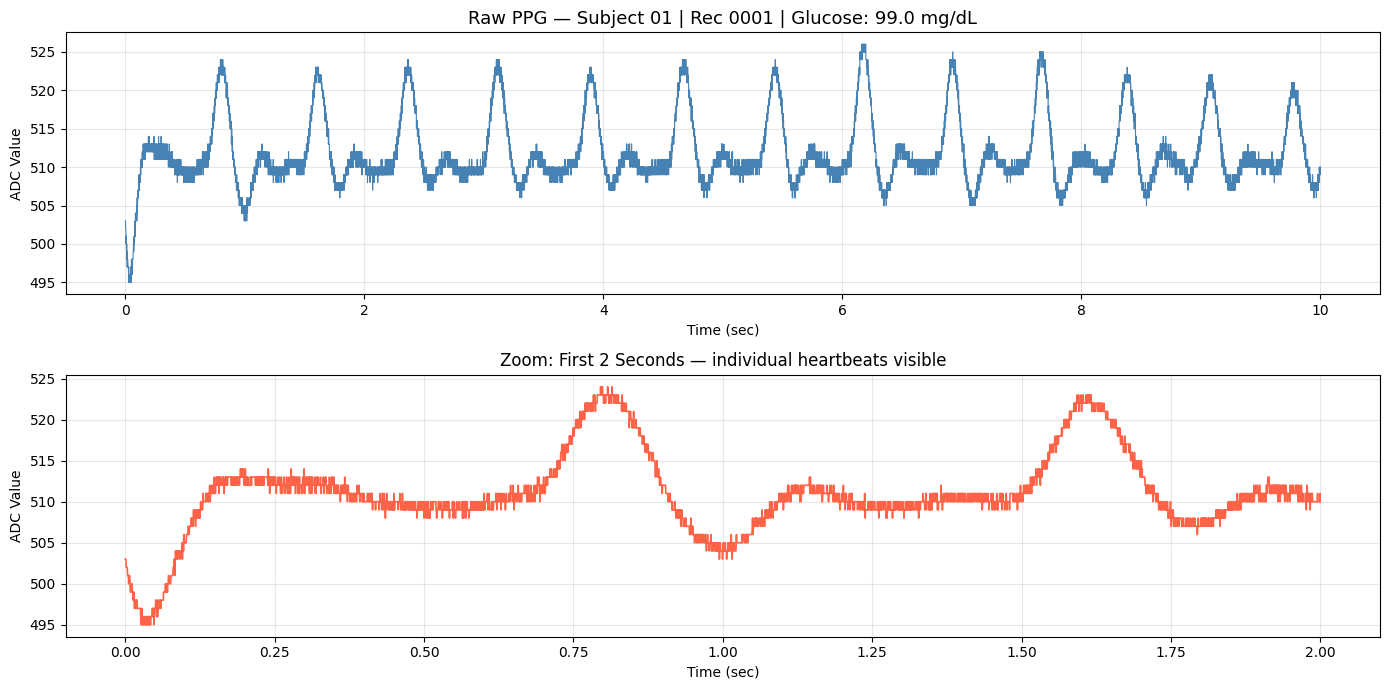

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

axes[0].plot(time, signal, color='steelblue', linewidth=0.8)
axes[0].set_title(
    f'Raw PPG — Subject {subj:02d} | Rec {rec:04d} | Glucose: {label["Glucose"]} mg/dL',
    fontsize=13
)
axes[0].set_xlabel('Time (sec)')
axes[0].set_ylabel('ADC Value')
axes[0].grid(True, alpha=0.3)

mask = time <= 2.0
axes[1].plot(time[mask], signal[mask], color='tomato', linewidth=1.2)
axes[1].set_title('Zoom: First 2 Seconds — individual heartbeats visible')
axes[1].set_xlabel('Time (sec)')
axes[1].set_ylabel('ADC Value')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Cell 6 — Dataset Summary & Glucose Distribution

=== Dataset Overview ===
Total recordings : 67
Total subjects   : 23

Recordings per subject:
subject
1     7
2     3
3     2
4     5
5     6
6     2
7     4
8     2
9     2
10    2
11    4
12    1
13    2
14    2
15    3
16    3
17    2
18    3
19    2
20    3
21    2
22    3
23    2

=== Label Statistics ===
         Age  Glucose  Height  Weight
count  67.00    67.00   67.00   67.00
mean   24.16    85.31  130.76   54.46
std    16.67    54.80   79.97   36.14
min     0.00     0.00    0.00    0.00
25%     0.00     0.00    0.00    0.00
50%    26.00   106.00  178.00   62.00
75%    38.00   116.50  180.00   88.00
max    51.00   183.00  187.00  103.00

Gender split: {'Female': 49, 'Male': 18}


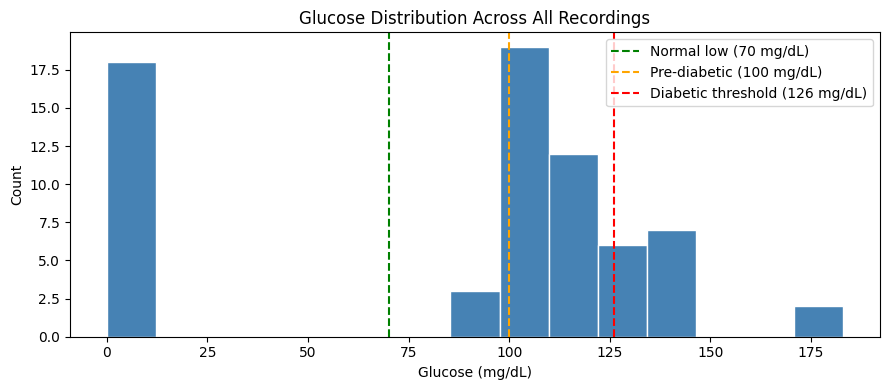

In [8]:
print('=== Dataset Overview ===')
print(f'Total recordings : {len(df)}')
print(f'Total subjects   : {df["subject"].nunique()}')
print()
print('Recordings per subject:')
print(df.groupby('subject')['recording'].count().to_string())
print()
print('=== Label Statistics ===')
print(df[['Age', 'Glucose', 'Height', 'Weight']].describe().round(2))
print()
print('Gender split:', df['Gender_str'].value_counts().to_dict())

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df['Glucose'], bins=15, color='steelblue', edgecolor='white')
ax.axvline(70,  color='green',  linestyle='--', linewidth=1.5, label='Normal low (70 mg/dL)')
ax.axvline(100, color='orange', linestyle='--', linewidth=1.5, label='Pre-diabetic (100 mg/dL)')
ax.axvline(126, color='red',    linestyle='--', linewidth=1.5, label='Diabetic threshold (126 mg/dL)')
ax.set_xlabel('Glucose (mg/dL)')
ax.set_ylabel('Count')
ax.set_title('Glucose Distribution Across All Recordings')
ax.legend()
plt.tight_layout()
plt.show()